In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [10]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260420-193104.mat"
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures"

In [11]:
vs = VoltageSummary(datapath)

In [33]:
vs.valid_trials[0]

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

In [34]:
dmd1_traces = vs.get_roi_traces(dmd=1,trial=4)
dmd2_traces = vs.get_roi_traces(dmd=2,trial=2)

In [35]:
dmd1_traces.shape

(99670, 15)

In [36]:
im_rate = dmd1_traces.shape[0]/1800

<IPython.core.display.Javascript object>


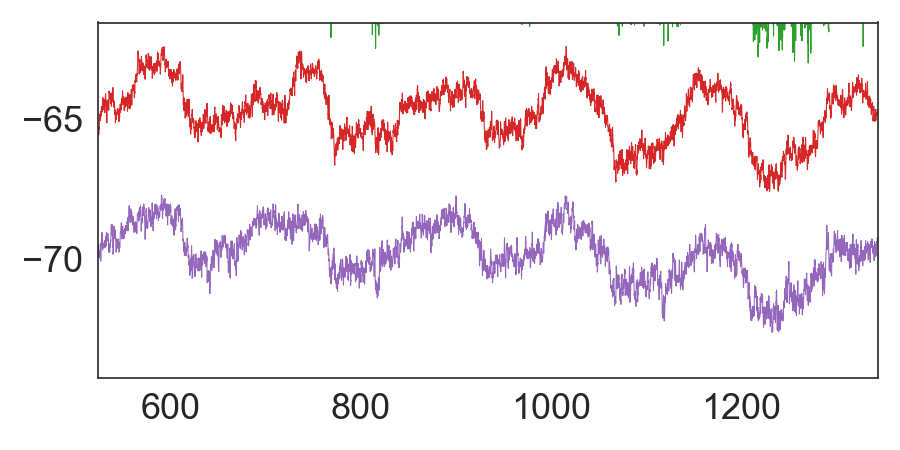

In [37]:
fig,ax=plt.subplots(figsize=(6,3))

offset = 5
time = np.linspace(0,dmd1_traces.shape[0]/im_rate,dmd1_traces.shape[0])

for roi in range(dmd1_traces.shape[1]):
    
    trace = dmd1_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],-trace[::]-offset*roi,lw=0.5)
    
    
fig.tight_layout()

In [ ]:
fig,ax=plt.subplots(figsize=(6,3))

offset = 5
time = np.linspace(0,dmd2_traces.shape[0]/im_rate,dmd2_traces.shape[0])

for roi in range(dmd2_traces.shape[1])[:]:
    
    trace = dmd2_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    ax.plot(time[::],-trace[::]-offset*roi,lw=0.5)

fig.tight_layout()

In [ ]:
rois_of_interest = [0,4,10,15]
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Bay',n_colors=len(rois_of_interest))
fig,ax=plt.subplots(figsize=(6,3))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

offset = 5
time = np.linspace(0,dmd2_traces.shape[0]/im_rate,dmd2_traces.shape[0])
window = (600000,900000)
for i,roi in enumerate(rois_of_interest):
    
    trace = dmd2_traces[::,roi]
    trace = (trace-np.mean(trace))/np.std(trace)
    
    rolling = pd.DataFrame(trace).rolling(20,min_periods=1).mean()
    
    ax.plot(time[window[0]:window[1]]-time[window[0]],
            -rolling[window[0]:window[1]]-offset*i,
            lw=1,
           color=cp[i])
yticks = -np.arange(len(rois_of_interest)) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(len(rois_of_interest)))   
ax.set_xlabel('Time (s)')
ax.set_ylabel('Dendrite ROI')

for spine in ['top','bottom','left','right']:
    ax.spines[spine].set_linewidth(2)
ax.set_title('Dendritic voltage imaging')
fig.tight_layout()